**Sobre o conjunto de dados**

**Contexto:**

Este conjunto de dados foi criado exclusivamente para fins de aprendizado dos conceitos de segmentação de clientes, também conhecida como análise de cesta de compras. Demonstrarei isso utilizando a técnica de aprendizado de máquina não supervisionado (algoritmo de agrupamento K-Means) em sua forma mais simples.

Você é dono de um supermercado e, por meio de cartões de fidelidade, possui dados básicos sobre seus clientes, como ID do cliente, idade, sexo, renda anual e pontuação de gastos.
A pontuação de gastos é atribuída ao cliente com base em parâmetros definidos, como comportamento do cliente e dados de compra.

**Problema:**

Você é proprietário do shopping e deseja entender o perfil dos clientes que frequentam o local para que a equipe de marketing possa elaborar estratégias adequadas.

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


###Importando a base de dados

In [31]:
!pwd

/content


In [32]:

#!/bin/bash
!curl -L -o /content/customer-segmentation-tutorial-in-python.zip\
  https://www.kaggle.com/api/v1/datasets/download/vjchoudhary7/customer-segmentation-tutorial-in-python


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  1583  100  1583    0     0   3822      0 --:--:-- --:--:-- --:--:--  3822


In [33]:
!unzip /content/customer-segmentation-tutorial-in-python.zip

Archive:  /content/customer-segmentation-tutorial-in-python.zip
replace Mall_Customers.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Mall_Customers.csv      


In [34]:
df = pd.read_csv('Mall_Customers.csv')

In [35]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Analisando a base de dados

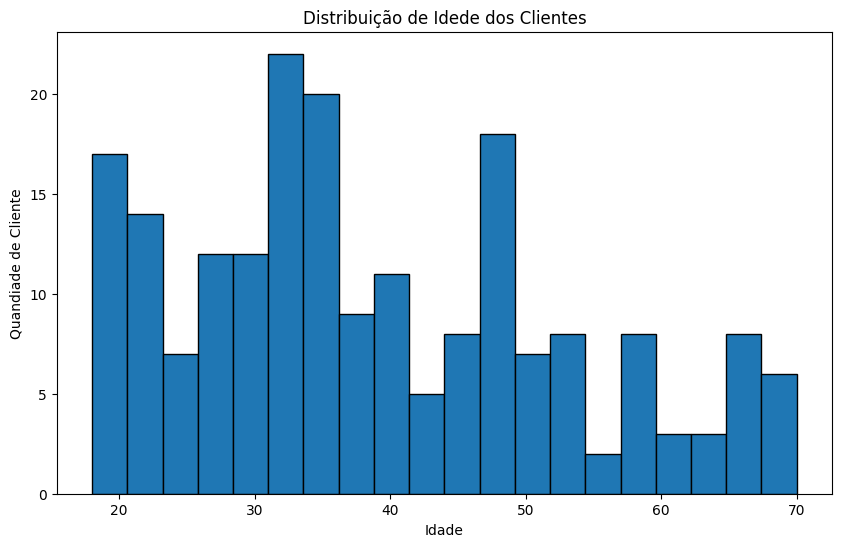

In [36]:
plt.figure(figsize=(10,6))
plt.hist(df['Age'], bins=20, edgecolor='black')

plt.title('Distribuição de Idede dos Clientes')
plt.xlabel('Idade')
plt.ylabel('Quandiade de Cliente')

plt.show()

A análise do histograma mostra que a maior concentração de clientes está entre 25 e 40 anos, com pico próximo dos 30–35 anos. Também é possível observar menor quantidade de clientes acima de 60 anos, indicando predominância de um público adulto jovem.

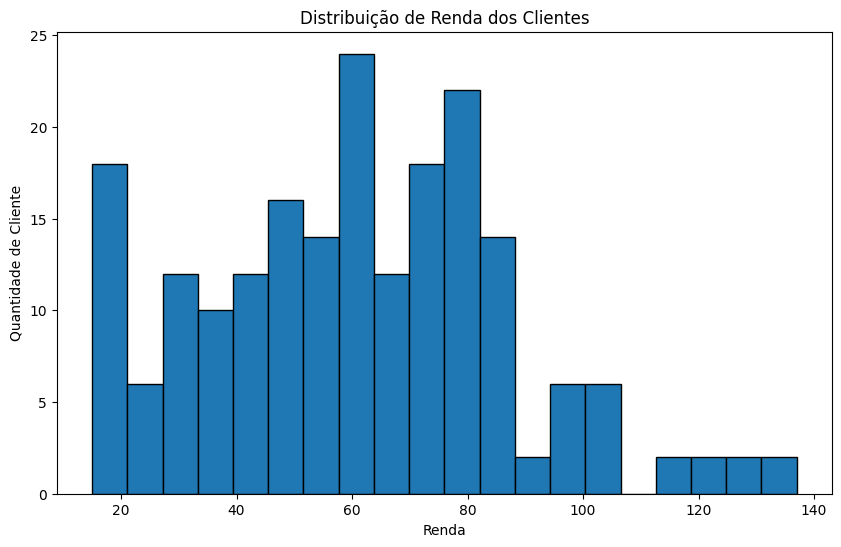

In [37]:
plt.figure(figsize=(10,6))
plt.hist(df['Annual Income (k$)'], bins= 20 , edgecolor='black')

plt.title('Distribuição de Renda dos Clientes')
plt.xlabel('Renda')
plt.ylabel('Quantidade de Cliente')

plt.show()

A análise da distribuição de renda mostra que a maior parte dos clientes possui renda anual entre 40k e 80k, com maior concentração próxima de 60k–80k. Também é possível observar poucos clientes com renda muito elevada, acima de 100k, indicando uma distribuição assimétrica.

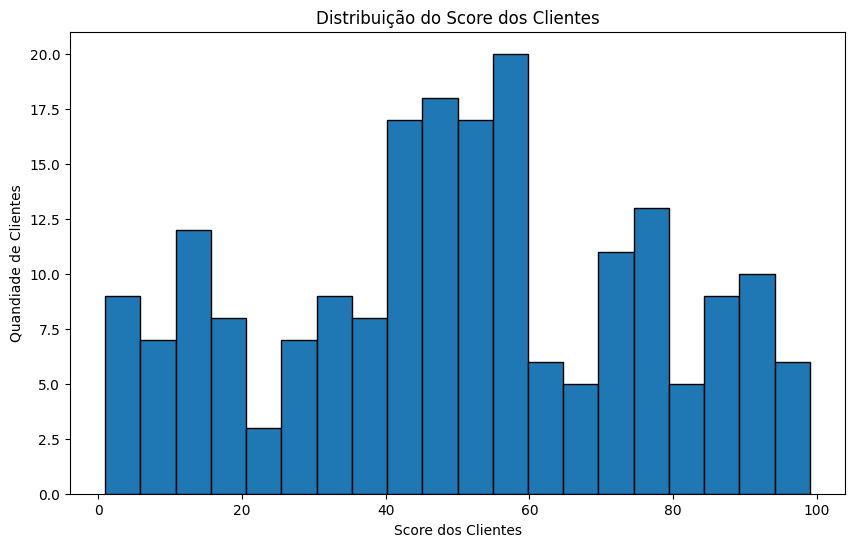

In [38]:
plt.figure(figsize=(10,6))
plt.hist(df['Spending Score (1-100)'] , bins=20 , edgecolor='black')

plt.title('Distribuição do Score dos Clientes')
plt.xlabel('Score dos Clientes')
plt.ylabel('Quandiade de Clientes')

plt.show()

A distribuição do Spending Score mostra que os clientes estão distribuídos em diversas faixas de consumo, com maior concentração entre 40 e 60 pontos. Também existem clientes com scores muito baixos e muito altos, indicando diferentes perfis de comportamento de compra.

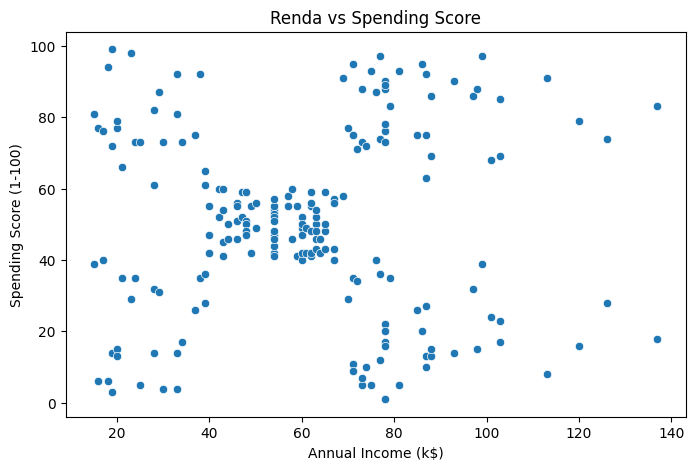

In [39]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title('Renda vs Spending Score')
plt.show()

A análise da relação entre renda anual e Spending Score mostra a existência de diferentes perfis de clientes. Observa-se grupos com alta renda e alto consumo, alta renda e baixo consumo, além de clientes com baixa renda e diferentes padrões de gasto. Isso sugere forte potencial para aplicação de técnicas de clustering como K-Means.

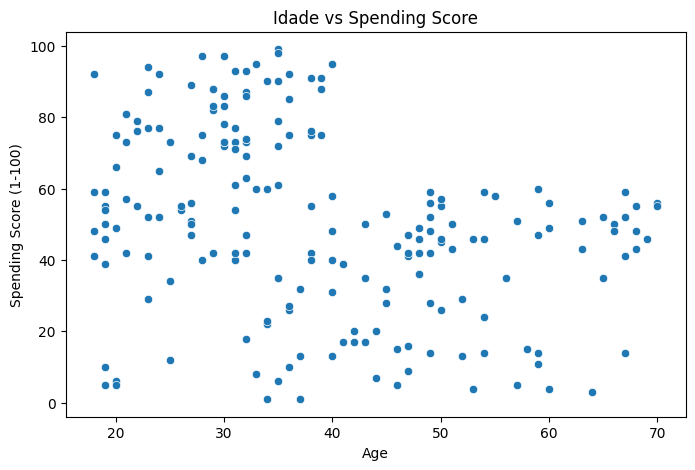

In [40]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Age',
    y='Spending Score (1-100)',
    data=df
)

plt.title('Idade vs Spending Score')
plt.show()

A análise da relação entre idade e Spending Score sugere que clientes mais jovens tendem a apresentar maiores níveis de consumo. Já clientes mais velhos apresentam comportamento mais moderado, concentrando-se em scores médios. Também foi observada maior variabilidade de consumo entre os clientes jovens.

###Pre-Processamento

In [41]:
#Removendo a coluna CustomerID

df.drop(columns=['CustomerID'], inplace=True)


In [42]:
#Utilizei o get_dummies() em vez do LabelEncoder para transformar a variável categórica Gender, evitando a criação de uma relação de ordem artificial entre as categorias 'Homem' e 'Mulher', já que não existe hierarquia ou valor ordinal entre elas.

df = pd.get_dummies(df , columns=['Gender'] , drop_first=True, dtype=int)

Aplicando a normalização porque as variáveis podem estar em escalas muito diferentes, e isso pode fazer com que algumas tenham mais influência que outras no modelo.

In [43]:
stand = StandardScaler()

In [44]:
#Fazendo uma cópia do df original

base_normalizada = df.copy()

In [45]:
base_normalizada[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']] = stand.fit_transform(
    base_normalizada[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])

In [46]:
base_normalizada = base_normalizada[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
base_normalizada.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


# Avaliando o melhor K para utilizar o K-means

### Método do Cotovelo (Elbow Method)

Método mais utilizado: calcula a soma dos erros dentro dos clusters para vários valores de K.

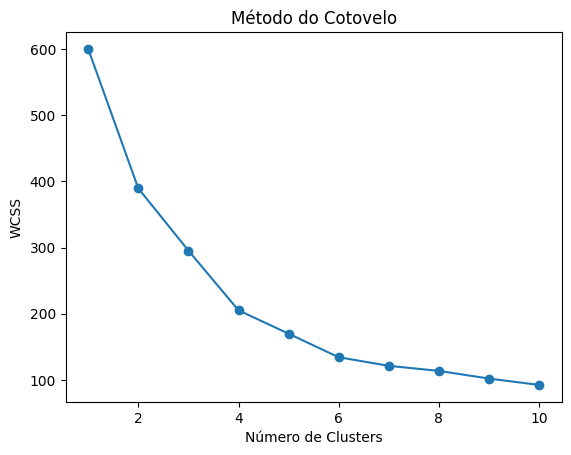

In [47]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(base_normalizada)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.title('Método do Cotovelo')
plt.show()

O gráfico do Método do Cotovelo indica que o melhor valor para K é 4, pois até esse ponto ocorre uma grande redução no WCSS (erro dentro dos clusters). Após K=4, a curva começa a se estabilizar, e o ganho obtido ao adicionar mais clusters passa a ser pequeno.

###Silhouette Score

In [48]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(base_normalizada)

    score = silhouette_score(base_normalizada, labels)
    print(f'K={k} -> Silhouette={score:.3f}')

K=2 -> Silhouette=0.335
K=3 -> Silhouette=0.358
K=4 -> Silhouette=0.404
K=5 -> Silhouette=0.408
K=6 -> Silhouette=0.431
K=7 -> Silhouette=0.410
K=8 -> Silhouette=0.367
K=9 -> Silhouette=0.374
K=10 -> Silhouette=0.362


O maior valor obtido foi 0,431 para K=6, indicando que essa configuração apresentou a melhor combinação entre coesão interna e separação entre grupos dentre os valores testados.

**Conclusão:** O Método do Cotovelo indicou que o número ideal de clusters é 4, pois a redução do WCSS torna-se menos significativa após esse ponto. A análise complementar com o Silhouette Score apresentou seu maior valor em K=6 (0,431), porém a diferença em relação a K=4 (0,404) foi pequena. Dessa forma, optou-se por utilizar 4 clusters, por oferecer um bom equilíbrio entre qualidade do agrupamento, simplicidade do modelo e facilidade de interpretação.

#Modelo K-means

In [49]:
# Criando o modelo

kmeans = KMeans(n_clusters=4, random_state=42)

In [50]:
# Treinando o modelo

kmeans.fit(base_normalizada)

KMeans(n_clusters=4, random_state=42)

In [51]:
# Obtendo o cluster de cada cliente

clusters = kmeans.labels_

In [52]:
# Adicionando ao DataFrame

base_normalizada['Cluster'] = clusters

#Aplicando o K-maens no dataset de origem

In [53]:
df['Cluster'] = clusters

Coloquei a coluna Cluster no dataset de origem para facilitar o entendimento do resultado com os dados não normalizados.

#Analisando o Resultado

In [54]:
#Agrupando os clusters com a média

df.groupby('Cluster')[['Age',
                       'Annual Income (k$)',
                       'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,53.984615,47.707692,39.969231
1,32.875000,86.100000,81.525000
2,25.438596,40.000000,60.298246
3,39.368421,86.500000,19.578947


Perfil
* 0	- Clientes mais velhos, renda média e gasto moderado/baixo
* 1	- Clientes com alta renda e alto gasto
* 2	-	Clientes jovens, renda menor e gasto moderado
* 3	-	Clientes com alta renda, mas baixo gasto

O modelo K-Means foi treinado utilizando os dados normalizados para evitar que diferenças de escala influenciassem a formação dos agrupamentos. Após a definição dos clusters, os rótulos foram associados ao conjunto de dados original, permitindo interpretar cada segmento utilizando os valores reais de idade, renda anual e nível de gastos.

#Conclusão da Análise

Com a aplicação do algoritmo K-Means, foi possível segmentar os clientes do shopping em quatro grupos distintos com base na idade, renda anual e nível de gastos. A análise revelou que existem perfis de consumidores com comportamentos bastante diferentes, mesmo entre clientes com rendas semelhantes.

Foi identificado um grupo de clientes com alta renda e alto nível de gastos, representando um segmento de grande valor para o shopping e que deve ser priorizado em ações de fidelização e benefícios exclusivos. Também foi encontrado um grupo de clientes com alta renda, mas baixo nível de gastos, indicando uma oportunidade para campanhas de marketing direcionadas que estimulem um maior consumo.

Além disso, a análise identificou segmentos de clientes mais jovens, com diferentes padrões de renda e consumo, bem como um grupo de clientes mais velhos com comportamento de compra mais moderado. Essas informações permitem compreender melhor o perfil dos frequentadores do shopping e suas características de consumo.

Dessa forma, o objetivo do estudo foi alcançado, pois a segmentação dos clientes fornece informações relevantes para que a equipe de marketing desenvolva estratégias mais personalizadas, aumentando a efetividade das campanhas, melhorando a experiência dos clientes e potencializando os resultados do negócio.